---
# EDA — PSM & SMD Datasets

This notebook covers exploratory data analysis for the **PSM (Pooled Server Metrics)** and **SMD (Server Machine Dataset)** benchmarks used in the MEMTO paper. Both are server-side multivariate time series datasets collected from real production infrastructure, and both are evaluated under the same unsupervised anomaly detection setup as SMAP and MSL.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, glob

BASE = 'dataset'

In [2]:
# ── Download all datasets from Google Drive ───────────────────────────────────
!gdown --folder https://drive.google.com/drive/folders/1gisthCoE-RrKJ0j3KPV7xiibhHWT9qRm -O dataset/

# ── Unzip PSM and SMD ─────────────────────────────────────────────────────────
!unzip -o dataset/Anomaly_Transformer/PSM.zip  -d dataset/
!unzip -o dataset/Anomaly_Transformer/SMD.zip  -d dataset/

Retrieving folder contents
Processing file 1BGeu0yiV4T_nsI1G2ayuGfLjIKw9ArZ_ MSL.zip
Processing file 1kohMqejb7f787XtpM4b5HR7G22nH-rEF PSM.zip
Processing file 1DRj6A4wFGx7SNEalGkEPzRi8Td8RdEK1 SMAP.zip
Processing file 187cjlXCedf4v3-Xm-fK7iTQZ6k6BFaDK SMD.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1BGeu0yiV4T_nsI1G2ayuGfLjIKw9ArZ_
To: /content/dataset/Anomaly_Transformer/MSL.zip
100% 767k/767k [00:00<00:00, 84.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1kohMqejb7f787XtpM4b5HR7G22nH-rEF
From (redirected): https://drive.google.com/uc?id=1kohMqejb7f787XtpM4b5HR7G22nH-rEF&confirm=t&uuid=ec9e6051-194a-4447-9228-08d3f794f66e
To: /content/dataset/Anomaly_Transformer/PSM.zip
100% 38.5M/38.5M [00:00<00:00, 134MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DRj6A4wFGx7SNEalGkEPzRi8Td8RdEK1
To: /content/dataset/Anomaly_Transformer/SMAP.zip
100

---
## 1. PSM (Pooled Server Metrics)

PSM is collected from internal compute nodes at eBay. It contains **26 features** representing server metrics such as CPU, memory, and network utilisation, sampled at 1-minute intervals. Unlike SMAP/MSL which use `.npy` arrays, PSM is stored as CSVs with a row-level timestamp index.

In [3]:
# ── Load ──────────────────────────────────────────────────────────────────────
psm_train  = pd.read_csv(f'{BASE}/PSM/train.csv')
psm_test   = pd.read_csv(f'{BASE}/PSM/test.csv')
psm_labels = pd.read_csv(f'{BASE}/PSM/test_label.csv')

# Drop the timestamp/index column from all splits (catches 'timestamp_(min)', 'Unnamed: 0', etc.)
for df in [psm_train, psm_test, psm_labels]:
    if 'timestamp' in df.columns[0].lower() or df.columns[0].lower() in ('', 'unnamed: 0'):
        df.drop(columns=df.columns[0], inplace=True)

print('=== PSM Shapes ===')
print(f'  Train    : {psm_train.shape}  ({psm_train.shape[0]:,} timesteps)')
print(f'  Test     : {psm_test.shape}  ({psm_test.shape[0]:,} timesteps)')
print(f'  Labels   : {psm_labels.shape}')
print(f'  Features : {psm_train.shape[1]}')
print(f'\n  Train/Test split : {psm_train.shape[0]/(psm_train.shape[0]+psm_test.shape[0]):.0%} / {psm_test.shape[0]/(psm_train.shape[0]+psm_test.shape[0]):.0%}')

=== PSM Shapes ===
  Train    : (132481, 25)  (132,481 timesteps)
  Test     : (87841, 25)  (87,841 timesteps)
  Labels   : (87841, 1)
  Features : 25

  Train/Test split : 60% / 40%


### 1.1 Missing Values

PSM's training set is notable for having missing values across several features — something not present in SMAP or MSL. This is important for MEMTO: the paper applies **linear interpolation** to fill NaNs before training. The test set has no missing values, so imputation is a train-only concern.

In [4]:
# ── Missing values ─────────────────────────────────────────────────────────────
train_missing = psm_train.isnull().sum()
test_missing  = psm_test.isnull().sum()

print('=== Missing Values ===')
print(f'  Train — features with NaN : {(train_missing > 0).sum()} / {len(train_missing)}')
print(f'  Test  — features with NaN : {(test_missing  > 0).sum()} / {len(test_missing)}')
if train_missing.any():
    missing_df = train_missing[train_missing > 0].rename('count').to_frame()
    missing_df['pct_of_train'] = (missing_df['count'] / len(psm_train) * 100).round(3)
    print('\n  Train NaN breakdown:')
    print(missing_df.to_string())

=== Missing Values ===
  Train — features with NaN : 12 / 25
  Test  — features with NaN : 0 / 25

  Train NaN breakdown:
            count  pct_of_train
feature_4     202         0.152
feature_5     249         0.188
feature_6     563         0.425
feature_7      47         0.035
feature_8      47         0.035
feature_10     47         0.035
feature_13    249         0.188
feature_14    202         0.152
feature_18    202         0.152
feature_21   2136         1.612
feature_22    204         0.154
feature_24     47         0.035


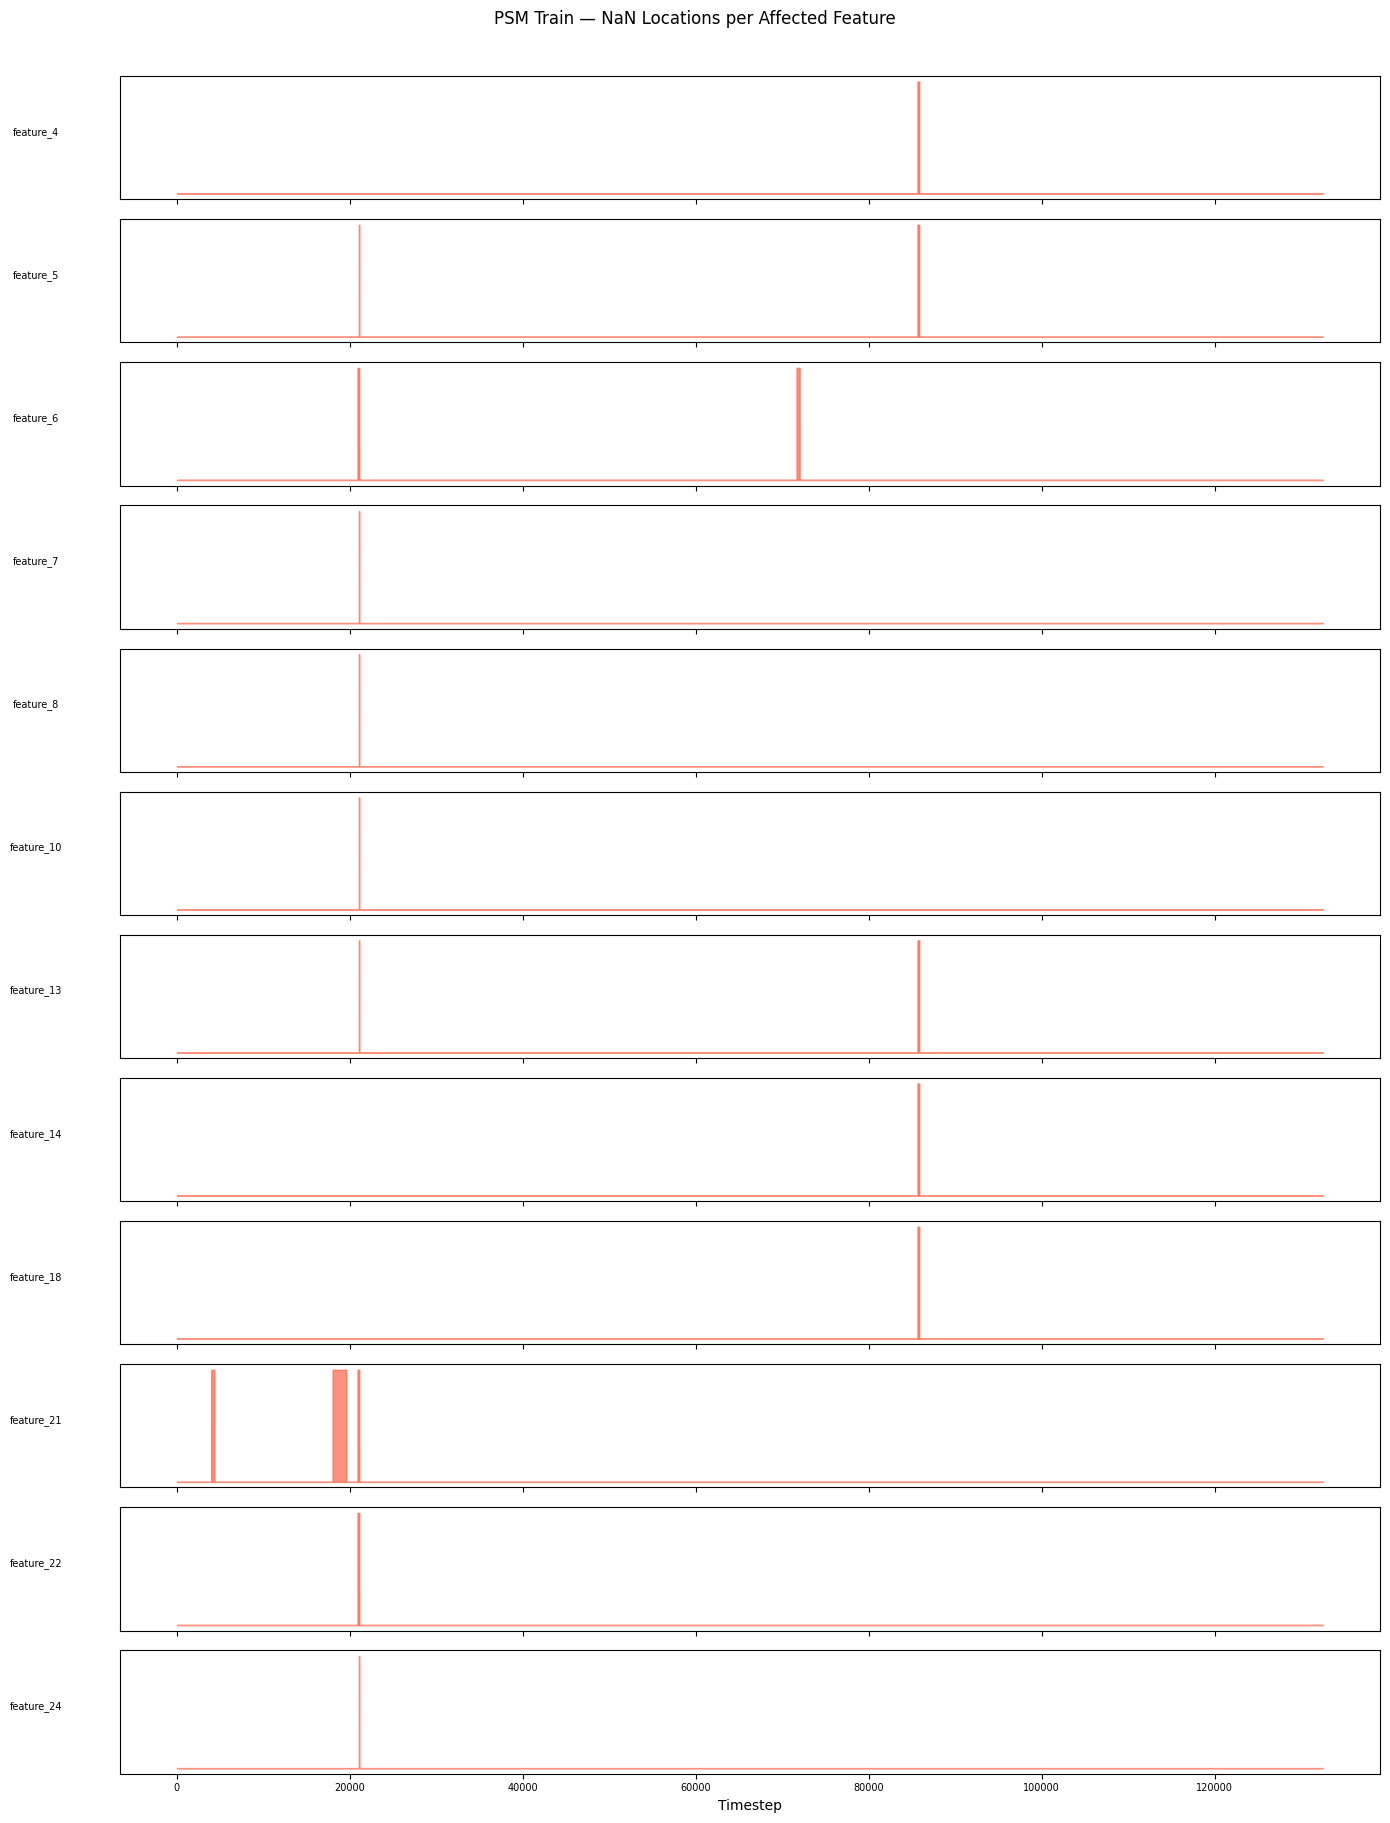

In [5]:
# ── NaN temporal distribution ─────────────────────────────────────────────────
# Check whether missing values cluster at the start/end or are spread throughout.
# This matters for interpolation quality — clustered gaps are harder to fill reliably.
nan_cols = train_missing[train_missing > 0].index.tolist()
fig, axes = plt.subplots(len(nan_cols), 1, figsize=(14, 1.5 * len(nan_cols)), sharex=True)
fig.suptitle('PSM Train — NaN Locations per Affected Feature', fontsize=12, y=1.01)

for ax, col in zip(axes, nan_cols):
    is_nan = psm_train[col].isnull().astype(int)
    ax.fill_between(range(len(is_nan)), is_nan, alpha=0.7, color='tomato')
    ax.set_ylabel(col, fontsize=7, rotation=0, labelpad=60)
    ax.set_yticks([])
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()

### 1.2 Anomaly Ratio

In [6]:
# ── Anomaly ratio ──────────────────────────────────────────────────────────────
label_col = psm_labels.columns[0]   # binary label column (0 = normal, 1 = anomaly)
n_anom    = int(psm_labels[label_col].sum())
n_total   = len(psm_labels)
print(f'=== PSM Anomaly Ratio ===')
print(f'  Anomalous timesteps : {n_anom:,} / {n_total:,}  ({100*n_anom/n_total:.2f}%)')
print(f'  Normal timesteps    : {n_total - n_anom:,} / {n_total:,}  ({100*(n_total-n_anom)/n_total:.2f}%)')

=== PSM Anomaly Ratio ===
  Anomalous timesteps : 24,381 / 87,841  (27.76%)
  Normal timesteps    : 63,460 / 87,841  (72.24%)


### 1.3 Anomaly Segment Analysis

Beyond the overall ratio, the **structure** of anomalies matters for MEMTO. The model reconstructs windows of length `win_size` (default 100), so knowing whether anomalies are isolated spikes or sustained contiguous segments helps contextualise what the model is being asked to detect.

=== PSM — Anomaly Segment Lengths ===
  Number of segments : 72
  Min length         : 1
  Max length         : 8861
  Mean length        : 338.6
  Median length      : 5.0
  Segments >= win_size (100) : 18 (25.0%)


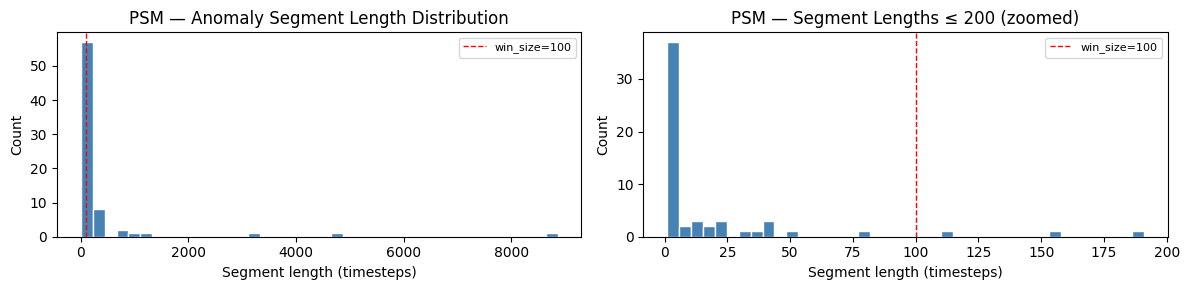

In [7]:
# ── Anomaly segment length distribution ───────────────────────────────────────
def get_segment_lengths(labels):
    """Return lengths of all contiguous anomaly runs."""
    segs, in_seg, length = [], False, 0
    for v in labels:
        if v == 1:
            in_seg = True
            length += 1
        elif in_seg:
            segs.append(length)
            in_seg, length = False, 0
    if in_seg:
        segs.append(length)
    return segs

psm_segs = get_segment_lengths(psm_labels[label_col].values)
psm_segs = np.array(psm_segs)

print('=== PSM — Anomaly Segment Lengths ===')
print(f'  Number of segments : {len(psm_segs)}')
print(f'  Min length         : {psm_segs.min()}')
print(f'  Max length         : {psm_segs.max()}')
print(f'  Mean length        : {psm_segs.mean():.1f}')
print(f'  Median length      : {np.median(psm_segs):.1f}')
print(f'  Segments >= win_size (100) : {(psm_segs >= 100).sum()} ({100*(psm_segs>=100).mean():.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(psm_segs, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(100, color='red', linestyle='--', linewidth=1, label='win_size=100')
axes[0].set_title('PSM — Anomaly Segment Length Distribution')
axes[0].set_xlabel('Segment length (timesteps)'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(psm_segs[psm_segs <= 200], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(100, color='red', linestyle='--', linewidth=1, label='win_size=100')
axes[1].set_title('PSM — Segment Lengths ≤ 200 (zoomed)')
axes[1].set_xlabel('Segment length (timesteps)'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 1.4 Feature Statistics

In [8]:
# ── Descriptive stats (train) ──────────────────────────────────────────────────
# All features are already normalised to [0, 1] in the PSM release,
# consistent with MEMTO's preprocessing which applies min-max normalisation.
print('=== PSM Train — Descriptive Stats (first 5 features) ===')
psm_train.iloc[:, :5].describe().round(3)

=== PSM Train — Descriptive Stats (first 5 features) ===


,feature_0,feature_1,feature_2,feature_3,feature_4
count,132481.000,132481.000,132481.000,132481.000,132279.000
mean,0.836,0.840,0.634,0.575,0.543
std,0.067,0.039,0.103,0.050,0.089
min,0.486,0.526,0.421,0.381,0.065
25%,0.789,0.820,0.580,0.544,0.471
50%,0.837,0.844,0.603,0.572,0.548
75%,0.881,0.866,0.626,0.611,0.605
max,1.000,0.910,1.000,0.677,0.929


In [9]:
# ── Feature value ranges ──────────────────────────────────────────────────────
feat_stats = pd.DataFrame({
    'min':   psm_train.min(),
    'max':   psm_train.max(),
    'mean':  psm_train.mean(),
    'std':   psm_train.std(),
    'range': psm_train.max() - psm_train.min()
}).round(3)
print('=== PSM — Feature Ranges (train) ===')
print(feat_stats.to_string())

# Flag near-zero variance features — these carry little signal
low_var = feat_stats[feat_stats['std'] < 0.01]
if not low_var.empty:
    print(f'\n  ⚠ Near-zero variance features: {low_var.index.tolist()}')

=== PSM — Feature Ranges (train) ===
              min    max   mean    std  range
feature_0   0.486  1.000  0.836  0.067  0.514
feature_1   0.526  0.910  0.840  0.039  0.384
feature_2   0.421  1.000  0.634  0.103  0.579
feature_3   0.381  0.677  0.575  0.050  0.296
feature_4   0.065  0.929  0.543  0.089  0.864
feature_5   0.110  0.877  0.512  0.078  0.767
feature_6   0.216  1.000  0.549  0.064  0.784
feature_7   0.078  0.968  0.538  0.090  0.890
feature_8   0.039  0.935  0.551  0.079  0.896
feature_9   0.040  0.916  0.545  0.081  0.876
feature_10  0.040  0.917  0.537  0.077  0.877
feature_11  0.055  1.000  0.594  0.092  0.945
feature_12  0.136  0.520  0.163  0.011  0.383
feature_13  0.125  0.509  0.148  0.010  0.384
feature_14  0.174  0.466  0.214  0.014  0.292
feature_15  0.126  1.000  0.396  0.040  0.874
feature_16  0.096  0.934  0.553  0.079  0.838
feature_17  0.459  0.920  0.626  0.050  0.460
feature_18  0.149  1.000  0.457  0.100  0.851
feature_19  0.503  1.000  0.659  0.034  0.4

### 1.5 Normal vs. Anomalous Feature Distributions

A key question for reconstruction-based models like MEMTO is whether anomalous timesteps are statistically distinguishable from normal ones in feature space. If the distributions overlap heavily, the model must rely on temporal context rather than feature magnitude alone.

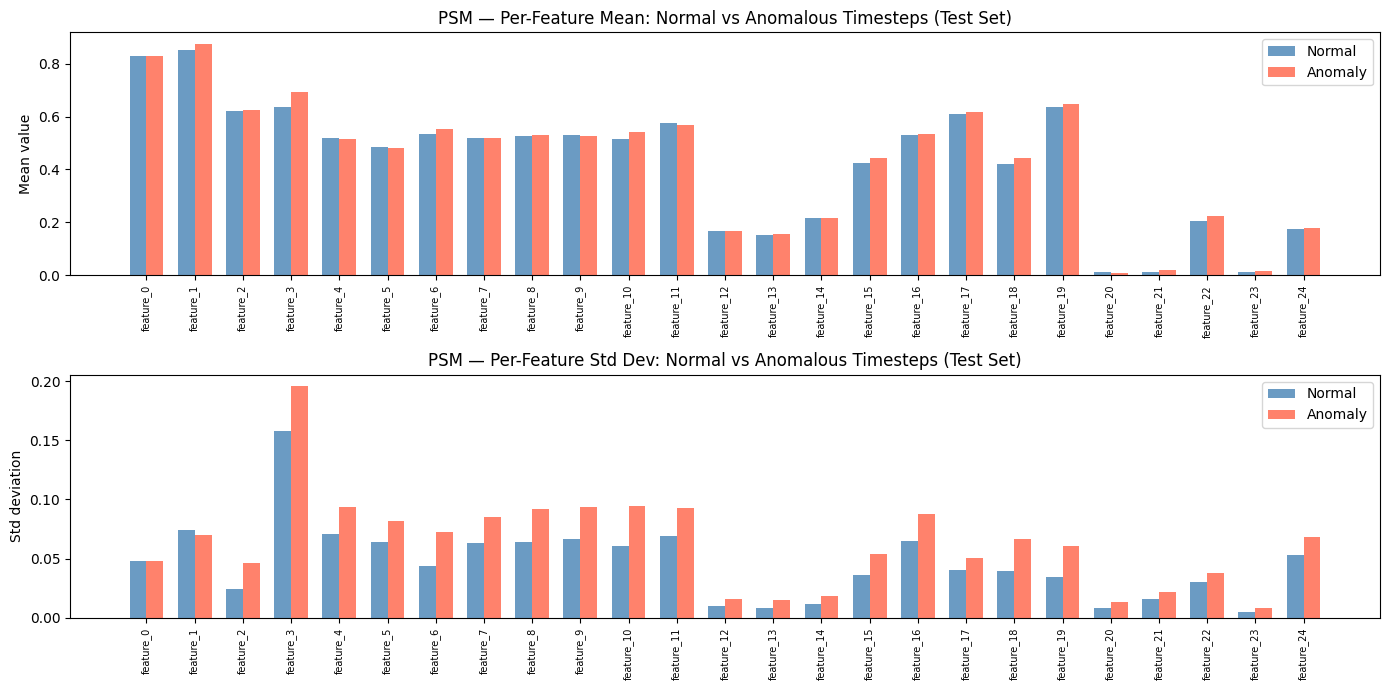

In [10]:
# ── Normal vs anomaly feature statistics ─────────────────────────────────────
lbl_arr = psm_labels[label_col].values
test_arr = psm_test.values

normal_mean = test_arr[lbl_arr == 0].mean(axis=0)
anom_mean   = test_arr[lbl_arr == 1].mean(axis=0)
normal_std  = test_arr[lbl_arr == 0].std(axis=0)
anom_std    = test_arr[lbl_arr == 1].std(axis=0)

feat_names = psm_test.columns.tolist()
x = np.arange(len(feat_names))
width = 0.35

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].bar(x - width/2, normal_mean, width, label='Normal', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, anom_mean,   width, label='Anomaly', color='tomato',    alpha=0.8)
axes[0].set_title('PSM — Per-Feature Mean: Normal vs Anomalous Timesteps (Test Set)')
axes[0].set_xticks(x); axes[0].set_xticklabels(feat_names, rotation=90, fontsize=7)
axes[0].set_ylabel('Mean value'); axes[0].legend()

axes[1].bar(x - width/2, normal_std, width, label='Normal', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, anom_std,   width, label='Anomaly', color='tomato',   alpha=0.8)
axes[1].set_title('PSM — Per-Feature Std Dev: Normal vs Anomalous Timesteps (Test Set)')
axes[1].set_xticks(x); axes[1].set_xticklabels(feat_names, rotation=90, fontsize=7)
axes[1].set_ylabel('Std deviation'); axes[1].legend()

plt.tight_layout()
plt.show()

### 1.6 Time Series Visualisation

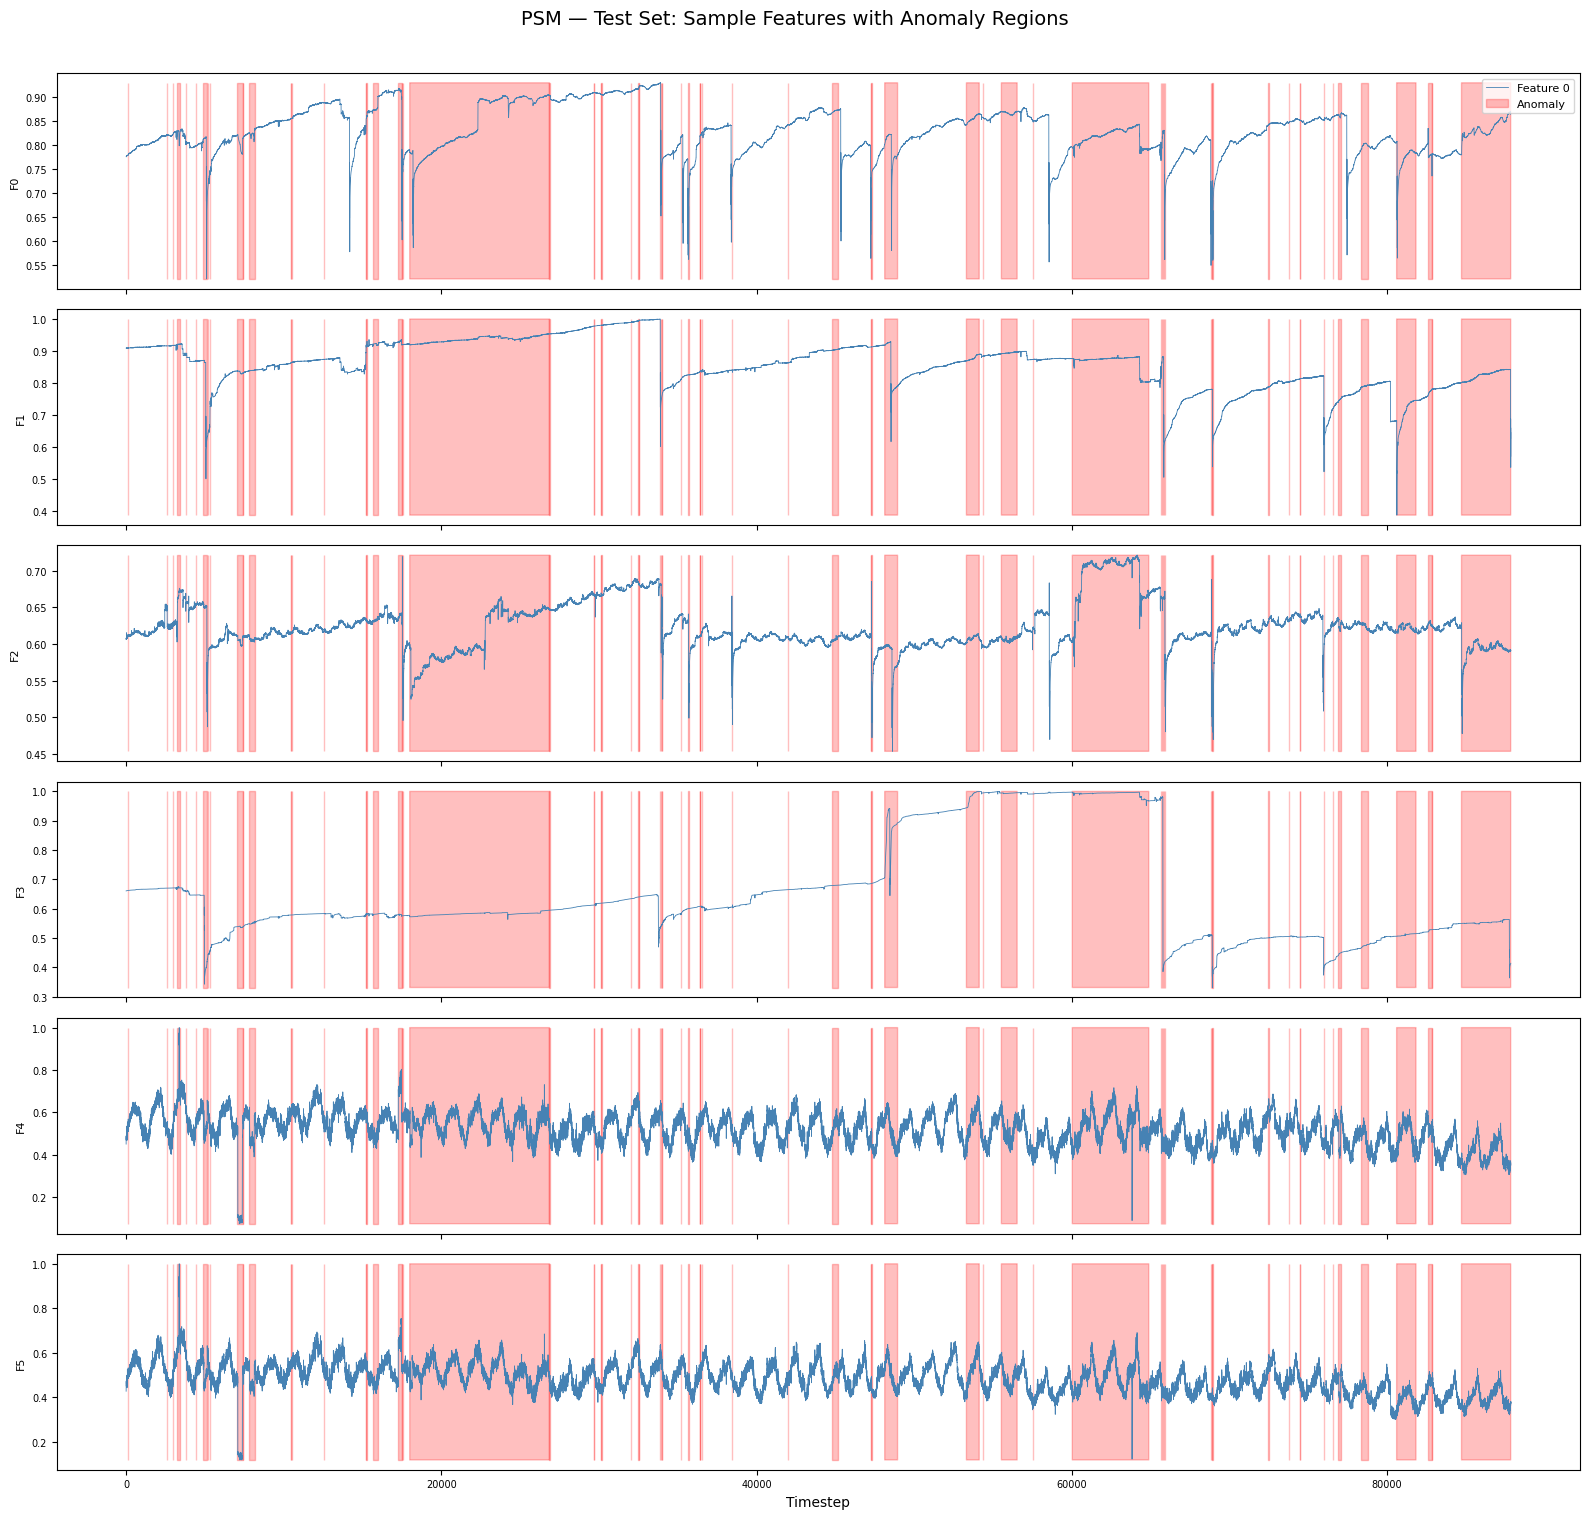

In [11]:
# ── Sample features + anomaly mask (test set) ─────────────────────────────────
# Red shading marks ground-truth anomaly windows.
N_FEAT_SHOW = 6

fig, axes = plt.subplots(N_FEAT_SHOW, 1, figsize=(16, 2.5 * N_FEAT_SHOW), sharex=True)
fig.suptitle('PSM — Test Set: Sample Features with Anomaly Regions', fontsize=14, y=1.01)

for i, ax in enumerate(axes):
    ax.plot(test_arr[:, i], linewidth=0.6, color='steelblue', label=f'Feature {i}')
    ax.fill_between(range(len(lbl_arr)),
                    test_arr[:, i].min(), test_arr[:, i].max(),
                    where=lbl_arr.astype(bool), alpha=0.25, color='red',
                    label='Anomaly' if i == 0 else '')
    ax.set_ylabel(f'F{i}', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()

### 1.7 Feature Correlation

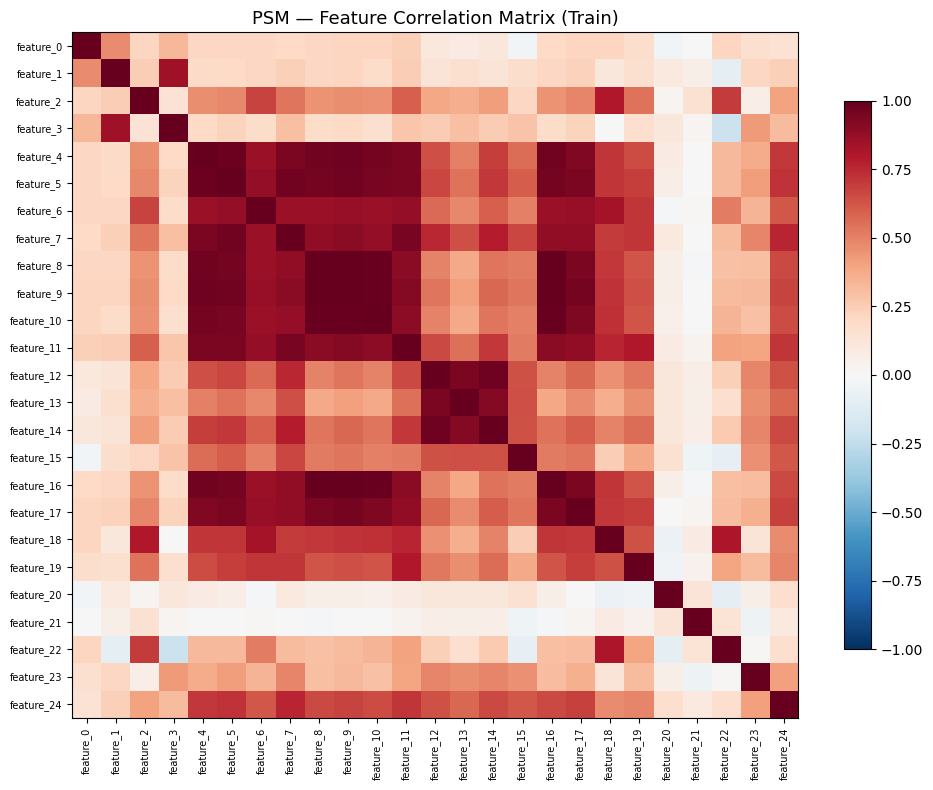

In [12]:
# ── Feature correlation heatmap (train) ───────────────────────────────────────
# High inter-feature correlation is beneficial for MEMTO: the memory module
# can leverage shared patterns across correlated features during reconstruction.
fig, ax = plt.subplots(figsize=(10, 8))
corr = psm_train.corr()
im   = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('PSM — Feature Correlation Matrix (Train)', fontsize=13)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
plt.tight_layout()
plt.show()

---
## 2. SMD (Server Machine Dataset)

SMD is collected from a large internet company and covers **28 server machines**, each monitored with **38 metrics** (CPU, memory, network I/O, disk, etc.). In the Anomaly Transformer release used by MEMTO, the per-machine files are pre-concatenated into a single train/test array, so we treat it as one large multivariate series. It is the largest of the four MEMTO benchmarks at ~700k timesteps per split.

In [13]:
# ── Inspect extracted file structure ──────────────────────────────────────────
smd_root = f'{BASE}/SMD'
for root, dirs, files in os.walk(smd_root):
    level = root.replace(smd_root, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:5]:
            print(f'{indent}  {f}')
        if len(files) > 5:
            print(f'{indent}  ... ({len(files)} files total)')

SMD/
  SMD_train.pkl
  SMD_train.npy
  SMD_test_label.pkl
  SMD_test.npy
  SMD_test.pkl
  ... (6 files total)


In [14]:
# ── Load ──────────────────────────────────────────────────────────────────────
smd_train  = np.load(f'{BASE}/SMD/SMD_train.npy')
smd_test   = np.load(f'{BASE}/SMD/SMD_test.npy')
smd_labels = np.load(f'{BASE}/SMD/SMD_test_label.npy')

print('=== SMD Shapes ===')
print(f'  Train    : {smd_train.shape}  ({smd_train.shape[0]:,} timesteps)')
print(f'  Test     : {smd_test.shape}  ({smd_test.shape[0]:,} timesteps)')
print(f'  Labels   : {smd_labels.shape}')
print(f'  Features : {smd_train.shape[1]}')
print(f'\n  Train/Test split : {smd_train.shape[0]/(smd_train.shape[0]+smd_test.shape[0]):.0%} / {smd_test.shape[0]/(smd_train.shape[0]+smd_test.shape[0]):.0%}')

=== SMD Shapes ===
  Train    : (708405, 38)  (708,405 timesteps)
  Test     : (708420, 38)  (708,420 timesteps)
  Labels   : (708420,)
  Features : 38

  Train/Test split : 50% / 50%


### 2.1 Missing Values & Data Quality

In [15]:
# ── Missing values & zero-variance features ────────────────────────────────────
nan_train = np.isnan(smd_train).sum()
nan_test  = np.isnan(smd_test).sum()
print(f'=== SMD Missing Values ===')
print(f'  Train NaN count : {nan_train}')
print(f'  Test  NaN count : {nan_test}')

# Zero-variance features are constant throughout training — they carry no signal
stds = smd_train.std(axis=0)
zero_var = np.where(stds < 1e-6)[0]
print(f'\n=== Zero-Variance Features ===')
if len(zero_var):
    print(f'  Features with std ≈ 0 : {zero_var.tolist()}')
    print(f'  These features are constant and contribute no information to the model.')
else:
    print('  None found.')

=== SMD Missing Values ===
  Train NaN count : 0
  Test  NaN count : 0

=== Zero-Variance Features ===
  Features with std ≈ 0 : [7]
  These features are constant and contribute no information to the model.


### 2.2 Anomaly Ratio

In [16]:
# ── Anomaly ratio ──────────────────────────────────────────────────────────────
lbl_smd = smd_labels.flatten()
n_anom  = int(lbl_smd.sum())
n_total = len(lbl_smd)
print('=== SMD Anomaly Ratio ===')
print(f'  Anomalous timesteps : {n_anom:,} / {n_total:,}  ({100*n_anom/n_total:.2f}%)')
print(f'  Normal timesteps    : {n_total-n_anom:,} / {n_total:,}  ({100*(n_total-n_anom)/n_total:.2f}%)')

=== SMD Anomaly Ratio ===
  Anomalous timesteps : 29,444 / 708,420  (4.16%)
  Normal timesteps    : 678,976 / 708,420  (95.84%)


### 2.3 Anomaly Segment Analysis

SMD has a noticeably lower anomaly ratio (~4%) than PSM. Here we look at whether that small fraction is made up of brief isolated spikes or longer episodes — again relevant to MEMTO's window size assumption.

=== SMD — Anomaly Segment Lengths ===
  Number of segments : 327
  Min length         : 2
  Max length         : 3161
  Mean length        : 90.0
  Median length      : 11.0
  Segments >= win_size (100) : 67 (20.5%)


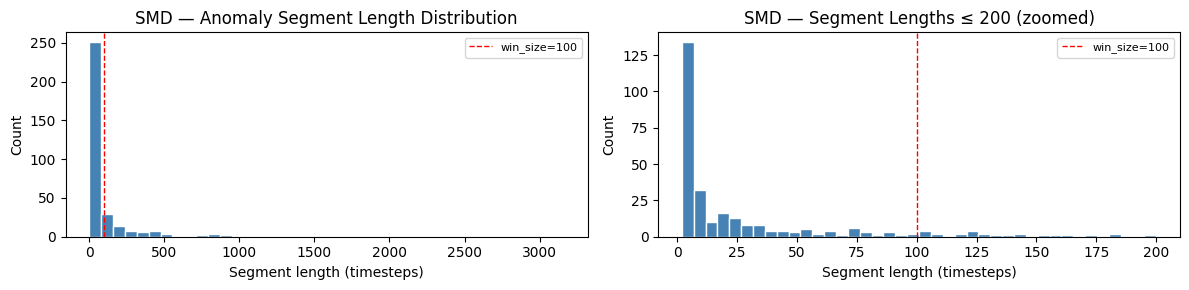

In [17]:
# ── Anomaly segment length distribution ───────────────────────────────────────
def get_segment_lengths(labels):
    segs, in_seg, length = [], False, 0
    for v in labels:
        if v == 1:
            in_seg = True
            length += 1
        elif in_seg:
            segs.append(length)
            in_seg, length = False, 0
    if in_seg:
        segs.append(length)
    return segs

smd_segs = np.array(get_segment_lengths(lbl_smd))

print('=== SMD — Anomaly Segment Lengths ===')
print(f'  Number of segments : {len(smd_segs)}')
print(f'  Min length         : {smd_segs.min()}')
print(f'  Max length         : {smd_segs.max()}')
print(f'  Mean length        : {smd_segs.mean():.1f}')
print(f'  Median length      : {np.median(smd_segs):.1f}')
print(f'  Segments >= win_size (100) : {(smd_segs >= 100).sum()} ({100*(smd_segs>=100).mean():.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(smd_segs, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(100, color='red', linestyle='--', linewidth=1, label='win_size=100')
axes[0].set_title('SMD — Anomaly Segment Length Distribution')
axes[0].set_xlabel('Segment length (timesteps)'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(smd_segs[smd_segs <= 200], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(100, color='red', linestyle='--', linewidth=1, label='win_size=100')
axes[1].set_title('SMD — Segment Lengths ≤ 200 (zoomed)')
axes[1].set_xlabel('Segment length (timesteps)'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2.4 Feature Statistics

In [18]:
# ── Basic statistics ───────────────────────────────────────────────────────────
# SMD features are normalised to [0, 1]. The near-zero means on many features
# suggest most metrics sit at low utilisation the majority of the time, with
# occasional spikes — a skewed distribution that can challenge reconstruction models.
print('=== SMD Train — Descriptive Stats (first 5 features) ===')
pd.DataFrame(smd_train).iloc[:, :5].describe().round(3)

=== SMD Train — Descriptive Stats (first 5 features) ===


,0,1,2,3,4
count,708405.000,708405.000,708405.000,708405.000,708405.000
mean,0.136,0.070,0.081,0.095,0.264
std,0.138,0.111,0.128,0.157,0.416
min,0.000,0.000,0.000,0.000,0.000
25%,0.032,0.003,0.005,0.006,0.000
50%,0.091,0.023,0.029,0.031,0.000
75%,0.194,0.082,0.088,0.097,0.652
max,1.000,1.000,1.000,1.000,1.000


In [19]:
# ── Feature value ranges ──────────────────────────────────────────────────────
feat_stats_smd = pd.DataFrame({
    'min':   smd_train.min(axis=0),
    'max':   smd_train.max(axis=0),
    'mean':  smd_train.mean(axis=0),
    'std':   smd_train.std(axis=0),
    'range': smd_train.max(axis=0) - smd_train.min(axis=0)
}).round(3)
print('=== SMD — Feature Ranges (train) ===')
print(feat_stats_smd.to_string())

=== SMD — Feature Ranges (train) ===
    min    max   mean    std  range
0   0.0  1.000  0.136  0.138  1.000
1   0.0  1.000  0.070  0.111  1.000
2   0.0  1.000  0.081  0.128  1.000
3   0.0  1.000  0.095  0.157  1.000
4   0.0  1.000  0.264  0.416  1.000
5   0.0  1.000  0.722  0.295  1.000
6   0.0  1.000  0.394  0.323  1.000
7   0.0  0.000  0.000  0.000  0.000
8   0.0  1.000  0.020  0.051  1.000
9   0.0  1.000  0.001  0.011  1.000
10  0.0  1.000  0.051  0.087  1.000
11  0.0  1.000  0.061  0.079  1.000
12  0.0  1.000  0.017  0.042  1.000
13  0.0  1.000  0.080  0.105  1.000
14  0.0  1.000  0.055  0.078  1.000
15  0.0  1.000  0.062  0.084  1.000
16  0.0  1.000  0.000  0.004  1.000
17  0.0  1.000  0.000  0.005  1.000
18  0.0  1.000  0.166  0.183  1.000
19  0.0  1.000  0.159  0.175  1.000
20  0.0  1.000  0.181  0.184  1.000
21  0.0  1.000  0.185  0.186  1.000
22  0.0  1.000  0.215  0.275  1.000
23  0.0  1.000  0.332  0.311  1.000
24  0.0  1.000  0.121  0.151  1.000
25  0.0  1.000  0.339  0.32

### 2.5 Normal vs. Anomalous Feature Distributions

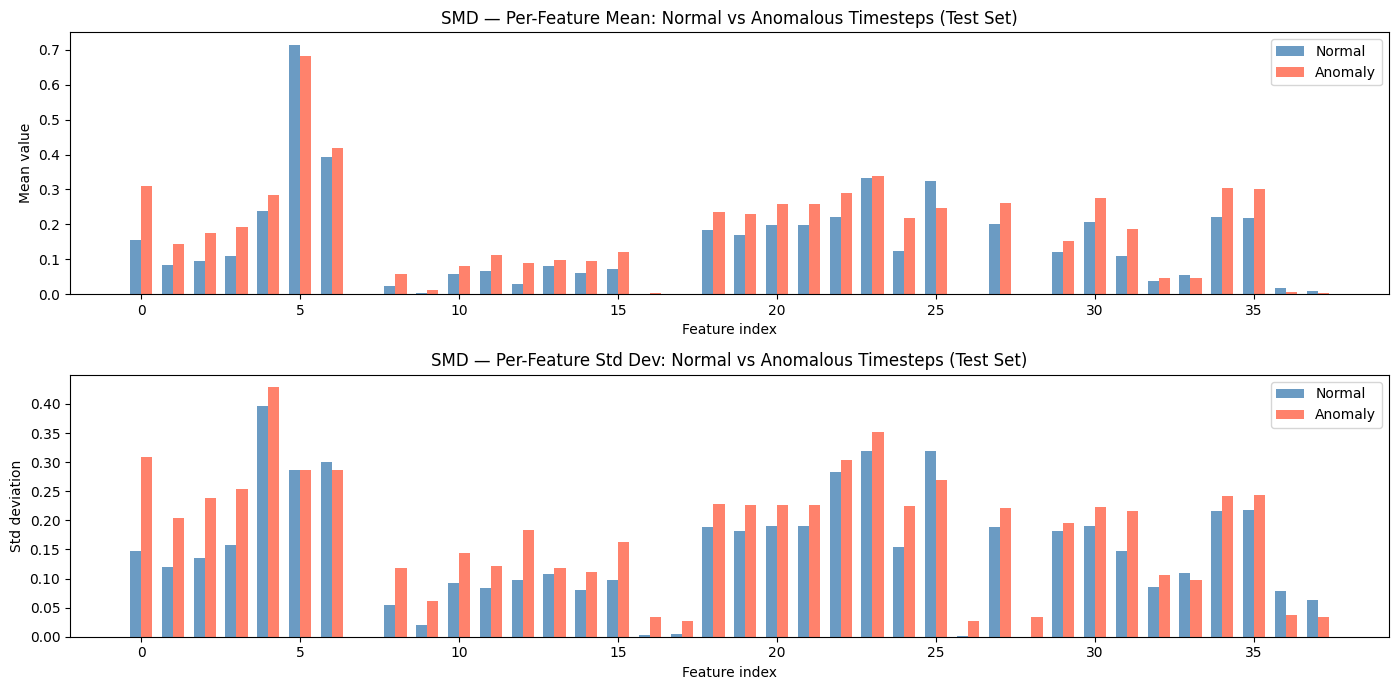

In [20]:
# ── Normal vs anomaly feature statistics ──────────────────────────────────────
normal_mean_smd = smd_test[lbl_smd == 0].mean(axis=0)
anom_mean_smd   = smd_test[lbl_smd == 1].mean(axis=0)
normal_std_smd  = smd_test[lbl_smd == 0].std(axis=0)
anom_std_smd    = smd_test[lbl_smd == 1].std(axis=0)

x = np.arange(smd_train.shape[1])
width = 0.35

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].bar(x - width/2, normal_mean_smd, width, label='Normal', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, anom_mean_smd,   width, label='Anomaly', color='tomato',   alpha=0.8)
axes[0].set_title('SMD — Per-Feature Mean: Normal vs Anomalous Timesteps (Test Set)')
axes[0].set_xlabel('Feature index'); axes[0].set_ylabel('Mean value'); axes[0].legend()

axes[1].bar(x - width/2, normal_std_smd, width, label='Normal', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, anom_std_smd,   width, label='Anomaly', color='tomato',   alpha=0.8)
axes[1].set_title('SMD — Per-Feature Std Dev: Normal vs Anomalous Timesteps (Test Set)')
axes[1].set_xlabel('Feature index'); axes[1].set_ylabel('Std deviation'); axes[1].legend()

plt.tight_layout()
plt.show()

### 2.6 Time Series Visualisation

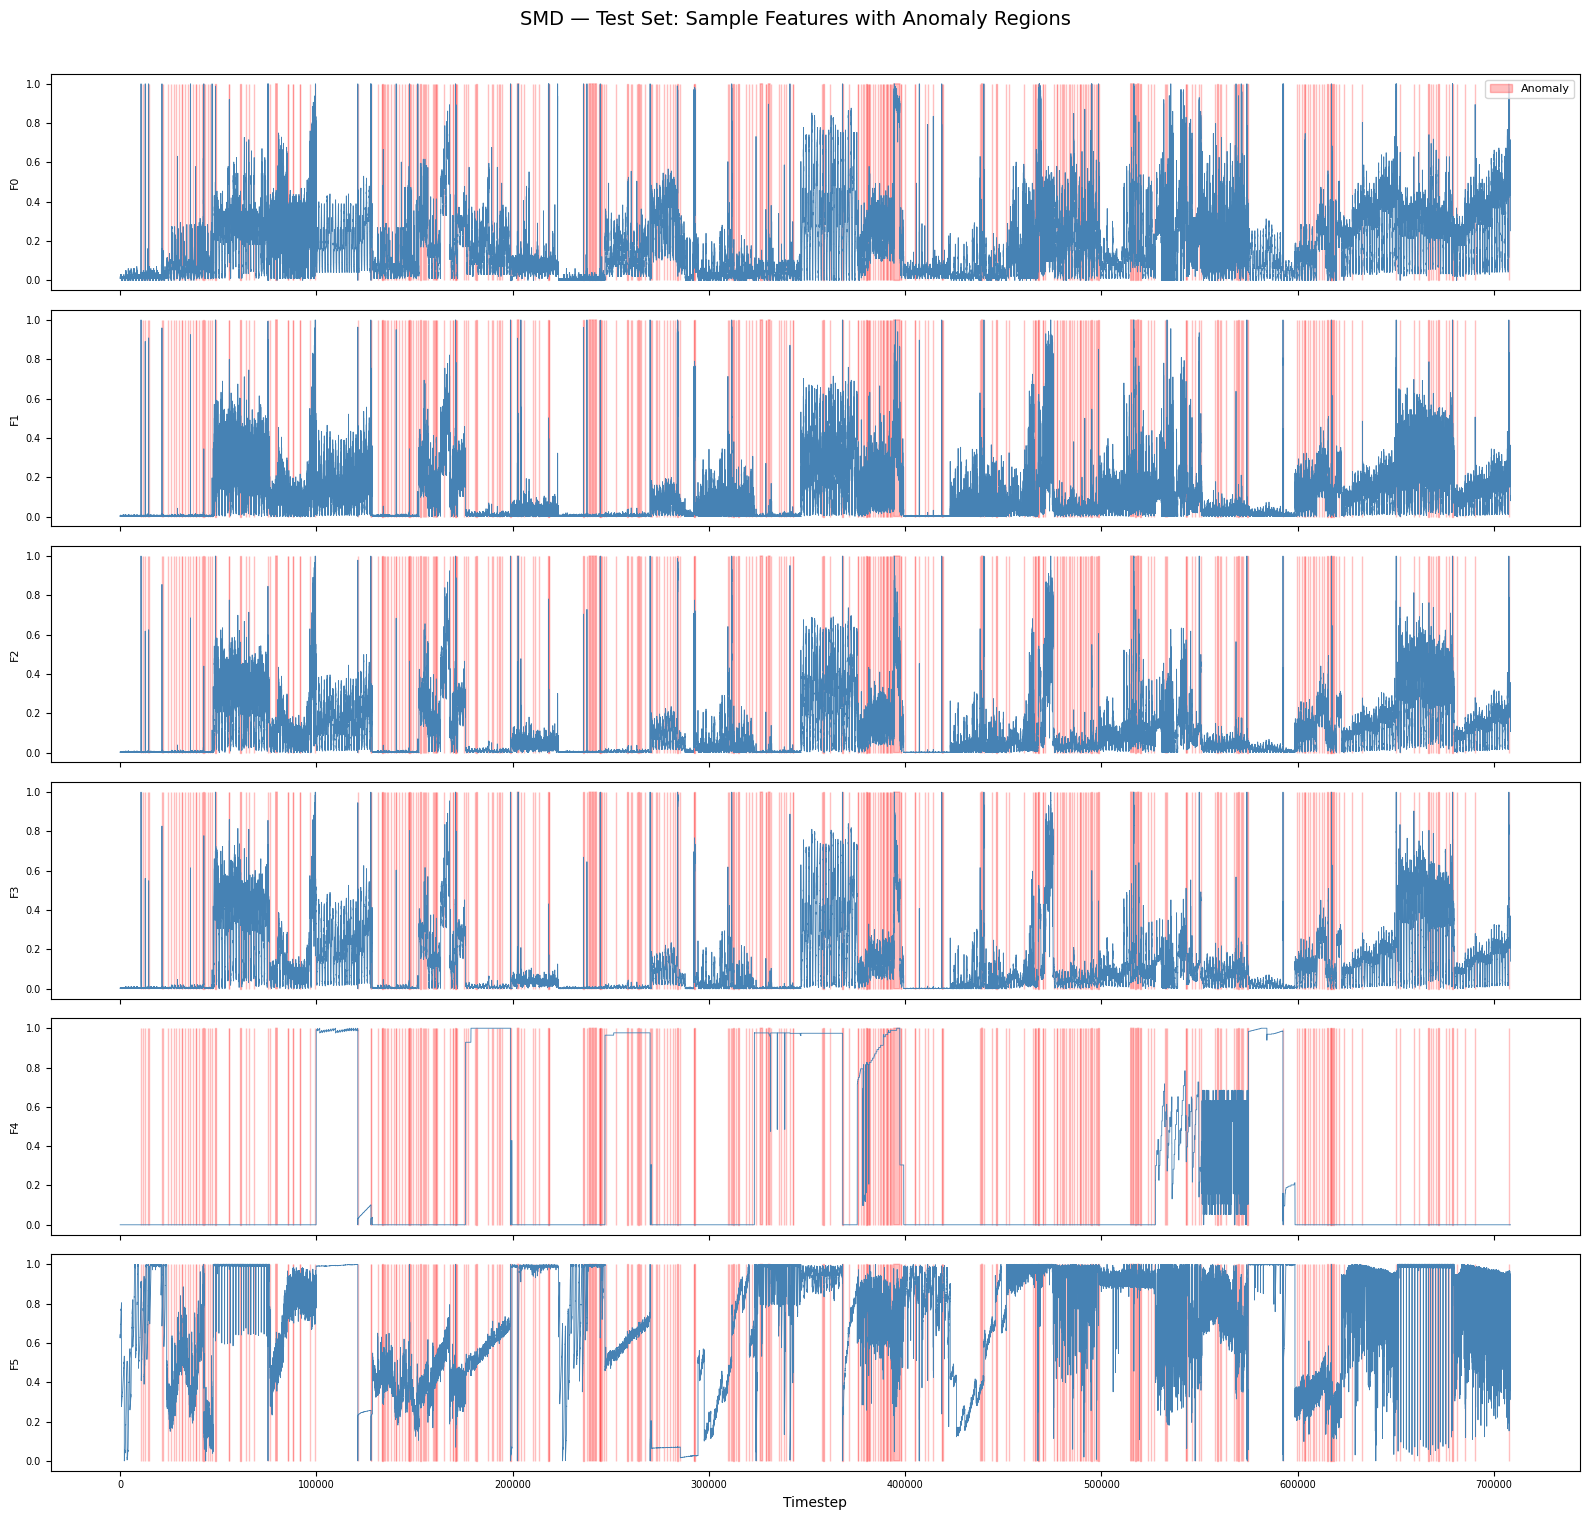

In [21]:
# ── Sample features + anomaly mask (test set) ─────────────────────────────────
N_FEAT_SHOW = 6

fig, axes = plt.subplots(N_FEAT_SHOW, 1, figsize=(16, 2.5 * N_FEAT_SHOW), sharex=True)
fig.suptitle('SMD — Test Set: Sample Features with Anomaly Regions', fontsize=14, y=1.01)

for i, ax in enumerate(axes):
    ax.plot(smd_test[:, i], linewidth=0.6, color='steelblue')
    ax.fill_between(range(len(lbl_smd)),
                    smd_test[:, i].min(), smd_test[:, i].max(),
                    where=lbl_smd.astype(bool), alpha=0.25, color='red',
                    label='Anomaly' if i == 0 else '')
    ax.set_ylabel(f'F{i}', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()

### 2.7 Feature Correlation

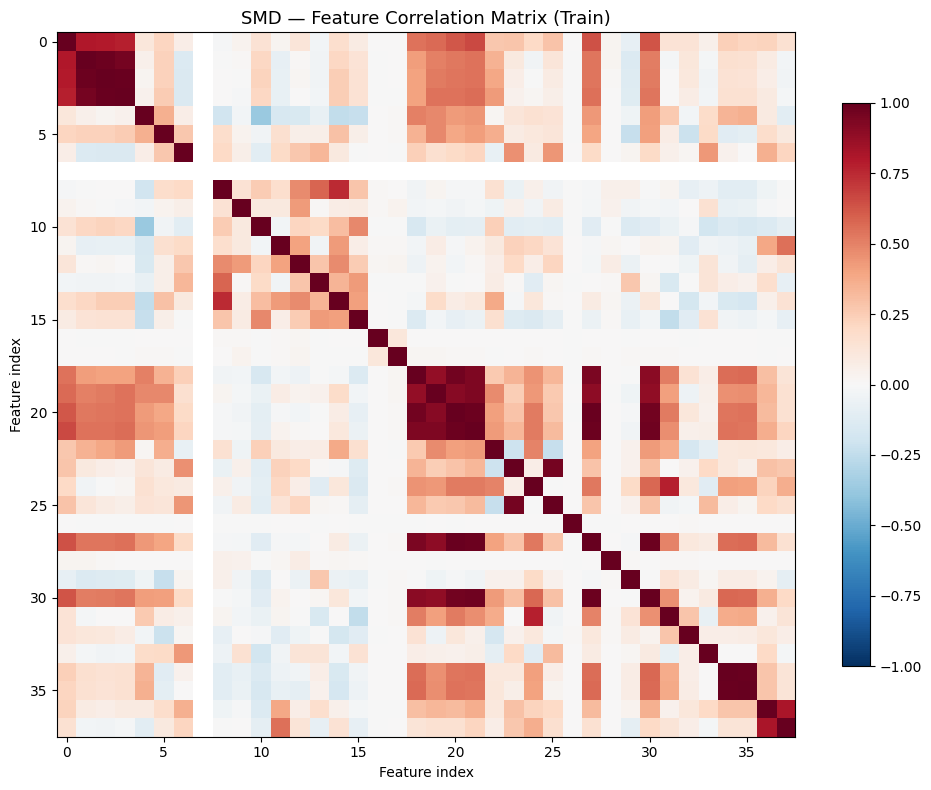

In [22]:
# ── Feature correlation heatmap (train) ───────────────────────────────────────
corr_smd = pd.DataFrame(smd_train).corr()
fig, ax  = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_smd.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('SMD — Feature Correlation Matrix (Train)', fontsize=13)
ax.set_xlabel('Feature index'); ax.set_ylabel('Feature index')
plt.tight_layout()
plt.show()

---
## 3. Dataset Comparison Summary

A side-by-side view of all four MEMTO benchmarks. The key takeaway is that the datasets vary considerably in size, dimensionality, and anomaly ratio — which is why MEMTO reports results on all four rather than cherry-picking.

In [23]:
# ── Cross-dataset summary table ───────────────────────────────────────────────
# SMAP and MSL values taken from the loaded data earlier in this notebook series.
# PSM and SMD values computed above.
summary = pd.DataFrame([
    {'Dataset': 'SMAP',
     'Train timesteps': '135,183',  'Test timesteps': '427,617',
     'Features': 25,  'Anomaly %': '13.13%',  'NaN in train': 'No',  'Format': '.npy'},
    {'Dataset': 'MSL',
     'Train timesteps': '58,317',   'Test timesteps': '73,729',
     'Features': 55,  'Anomaly %': '10.72%',  'NaN in train': 'No',  'Format': '.npy'},
    {'Dataset': 'PSM',
     'Train timesteps': f'{psm_train.shape[0]:,}',
     'Test timesteps':  f'{psm_test.shape[0]:,}',
     'Features': psm_train.shape[1],
     'Anomaly %': f'{100*n_anom/len(psm_labels):.2f}%',
     'NaN in train': f'Yes ({(train_missing > 0).sum()} features)',
     'Format': '.csv'},
    {'Dataset': 'SMD',
     'Train timesteps': f'{smd_train.shape[0]:,}',
     'Test timesteps':  f'{smd_test.shape[0]:,}',
     'Features': smd_train.shape[1],
     'Anomaly %': f'{100*int(lbl_smd.sum())/len(lbl_smd):.2f}%',
     'NaN in train': 'No',
     'Format': '.npy'},
])
summary.set_index('Dataset', inplace=True)
print('=== MEMTO Benchmark Datasets — Summary ===')
summary

=== MEMTO Benchmark Datasets — Summary ===


,Train timesteps,Test timesteps,Features,Anomaly %,NaN in train,Format
Dataset,,,,,,
SMAP,"135,183","427,617",25,13.13%,No,.npy
MSL,"58,317","73,729",55,10.72%,No,.npy
PSM,"132,481","87,841",25,33.52%,Yes (12 features),.csv
SMD,"708,405","708,420",38,4.16%,No,.npy
